# PacifyIQ — 01 · Dataset Audit (Phase 2)

Structural and quality checks on every asset before any analysis.

**Nothing here assumes column names or distributions.** Everything is derived from
the files as they exist on disk.

In [2]:
import sys, pathlib

# Locate the project root by walking up until we find src/.
# Works whether the kernel starts in notebooks/ or the workspace root.
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("interpreter: ", sys.executable)
print("project root:", ROOT)

import pandas as pd
from src.eda import loaders, plots, text_stats, audit

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plots.setup()

interpreter:  c:\DS-AI-Spiced\PacifyIQ_GenAI_Customer_Support_Platform\.venv\Scripts\python.exe
project root: c:\DS-AI-Spiced\PacifyIQ_GenAI_Customer_Support_Platform\pacifyiq\pacifyiq


## Inventory

What assets exist and how large are they?

In [3]:
for name, fn in [("tickets", loaders.load_tickets),
                 ("intent train", loaders.load_intent_train),
                 ("intent test", loaders.load_intent_test),
                 ("orders", loaders.load_orders),
                 ("customers", loaders.load_customers),
                 ("products", loaders.load_products),
                 ("corpus pages", loaders.load_corpus)]:
    df = fn()
    print(f"{name:16s} {df.shape[0]:6,} rows x {df.shape[1]:2d} cols")

tickets          11,905 rows x 21 cols
intent train      2,200 rows x  3 cols
intent test         142 rows x  6 cols
orders            2,001 rows x 31 cols
customers           500 rows x 11 cols
products             14 rows x  9 cols
corpus pages         47 rows x  7 cols


## Column profiles

Dtype, nulls, cardinality and a sample value for every column.

In [4]:
tickets = loaders.load_tickets()
audit.profile_columns(tickets)

,column,dtype,nulls,null_pct,unique,card_pct,sample
0,ticket_id,string,0,0.0,11905,100.0,TKT-40040
1,created_at,datetime64[us],0,0.0,11275,94.7,2026-02-20 09:12:00
2,intent,category,0,0.0,11,0.1,technical_support
3,subtopic,category,0,0.0,57,0.5,overheating
4,sentiment,category,0,0.0,3,0.0,neutral
5,priority,category,0,0.0,3,0.0,low
6,resolved_by,category,0,0.0,2,0.0,ai
7,status,category,0,0.0,2,0.0,resolved
8,confidence,float64,0,0.0,852,7.2,0.803
9,latency_seconds,float64,0,0.0,358,3.0,1.56


In [5]:
train = loaders.load_intent_train()
audit.profile_columns(train)

,column,dtype,nulls,null_pct,unique,card_pct,sample
0,text,string,0,0.0,2200,100.0,the tracking hasnt updated in 4...
1,intent,category,0,0.0,11,0.5,order_tracking
2,split,str,0,0.0,1,0.0,train


In [6]:
orders = loaders.load_orders()
audit.profile_columns(orders)

,column,dtype,nulls,null_pct,unique,card_pct,sample
0,order_id,str,0,0.0,2001,100.0,PAC-2026-12345
1,customer_id,str,0,0.0,488,24.4,CUS-10001
2,customer_name,str,0,0.0,488,24.4,Oni Kannan
3,region,str,0,0.0,2,0.1,IN
4,country,str,0,0.0,7,0.3,India
5,is_business,int64,0,0.0,2,0.1,0
6,sku,str,0,0.0,14,0.7,PB14
7,product_name,str,0,0.0,14,0.7,Pacify ProBook 14
8,category,str,0,0.0,5,0.2,laptop
9,brand,str,0,0.0,3,0.1,Pacify


## Full audit

Duplicates, missingness, timestamp validity, numeric ranges, categorical
integrity, PII scanning and leakage checks across all five assets.

In [7]:
for result in audit.run_all():
    print(result.report())


AUDIT: tickets/ticket_history.csv
shape: 11,905 rows x 21 columns

         column          dtype  nulls  null_pct  unique  card_pct                sample
      ticket_id         string      0       0.0   11905     100.0             TKT-40040
     created_at datetime64[us]      0       0.0   11275      94.7   2026-02-20 09:12:00
         intent       category      0       0.0      11       0.1     technical_support
       subtopic       category      0       0.0      57       0.5           overheating
      sentiment       category      0       0.0       3       0.0               neutral
       priority       category      0       0.0       3       0.0                   low
    resolved_by       category      0       0.0       2       0.0                    ai
         status       category      0       0.0       2       0.0              resolved
     confidence        float64      0       0.0     852       7.2                 0.803
latency_seconds        float64      0       0.0     

## Issue investigation

The audit flags problems. Here we look at what it found.

### Issue 1 — Sunday tickets contradict stated support hours

In [8]:
dow = tickets["weekday"].value_counts()
print(dow)
print(f"\nSunday: {dow.get('Sunday', 0)} tickets ({100*dow.get('Sunday',0)/len(tickets):.1f}%)")
print("POL-CS-001 S1.2 states support does not operate on Sundays.")

weekday
Friday       2120
Thursday     2046
Wednesday    2045
Tuesday      2043
Monday       2040
Saturday     1113
Sunday        498
Name: count, dtype: int64

Sunday: 498 tickets (4.2%)
POL-CS-001 S1.2 states support does not operate on Sundays.


### Issue 2 — Train/test leakage

In [9]:
test = loaders.load_intent_test()
tr_norm = set(train["text"].str.lower().str.strip())
leaked = [t for t in test["text"] if t.lower().strip() in tr_norm]
for t in leaked:
    print(repr(t))

'when will i get my money back'
'how long does a warranty repair take'


### Issue 3 — Confidence leakage

Confidence was generated from `resolved_by`, so it trivially predicts escalation.

            count      mean       std
escalated                            
False      7878.0  0.815387  0.124778
True       4027.0  0.460633  0.137746


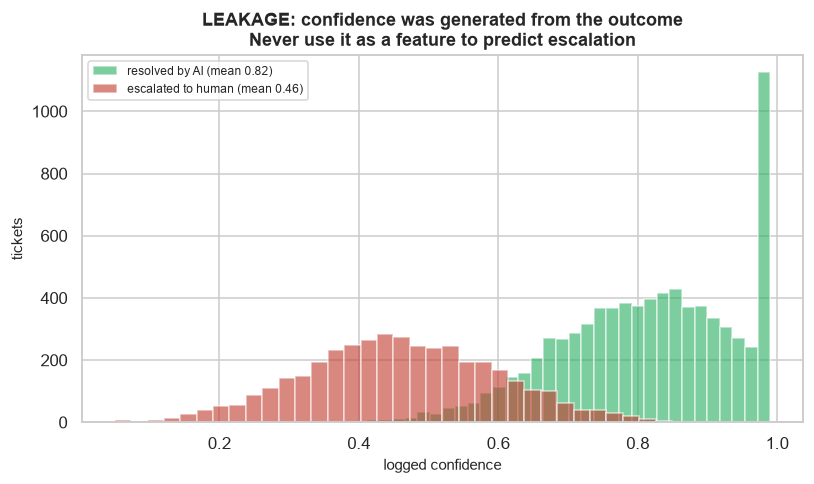

In [10]:
print(tickets.groupby("escalated")["confidence"].describe()[["count","mean","std"]])
plots.fig_confidence_leakage(tickets, save=False)

## Numeric distributions and outliers

In [11]:
for col in ["confidence", "latency_seconds", "tokens_used"]:
    print(f"{col}:")
    for k, v in audit.numeric_outliers(tickets[col]).items():
        print(f"   {k:14s} {v}")
    print()

confidence:
   q1             0.536
   q3             0.866
   lower_fence    0.041
   upper_fence    1.361
   n_outliers     0
   min            0.05
   max            0.99

latency_seconds:
   q1             1.35
   q3             2.15
   lower_fence    0.15
   upper_fence    3.35
   n_outliers     146
   min            0.4
   max            4.72

tokens_used:
   q1             1753.0
   q3             3392.0
   lower_fence    -705.5
   upper_fence    5850.5
   n_outliers     0
   min            900.0
   max            4200.0



## PII scan

In [12]:
print("train.csv:", audit.detect_pii(train["text"]))
print("test_hard.csv:", audit.detect_pii(test["text"]))

train.csv: {'email': 0, 'phone_in': 0, 'card_like': 0, 'aadhaar_like': 0, 'ifsc': 0, 'url': 0}
test_hard.csv: {'email': 0, 'phone_in': 0, 'card_like': 0, 'aadhaar_like': 0, 'ifsc': 0, 'url': 0}


## Screenshot / image availability

Checked explicitly because the system is designed to be multimodal.

In [13]:
for name, df in [("tickets", tickets), ("train", train), ("test", test), ("orders", orders)]:
    img_cols = [c for c in df.columns
                if any(k in c.lower() for k in ("image","screenshot","attach","file","photo"))]
    print(f"{name:10s} image-related columns: {img_cols or 'NONE'}")

print("\nScreenshots are specified in data/eval/vision_eval.json (25 cases)")
print("but the PNG files do not exist yet - they are generated in Phase 8.")

tickets    image-related columns: NONE
train      image-related columns: NONE
test       image-related columns: NONE
orders     image-related columns: NONE

Screenshots are specified in data/eval/vision_eval.json (25 cases)
but the PNG files do not exist yet - they are generated in Phase 8.


---

## Audit conclusions

See `reports/eda_findings.md` for the full write-up. Headline items:

1. **Confidence is leaked** — never use it as a feature to predict escalation
2. **2 texts overlap** between train and test — must be removed
3. **498 Sunday tickets** contradict the stated support policy
4. **No free-text column** in ticket history — it is aggregate metadata
5. **No image columns** anywhere — screenshots are Phase 8 work